# BIFROST Bragg peak monitor

This notebook demonstrates how to process data for BIFROST's Bragg peak monitor.
It uses a dedicated single crystal diffraction workflow to construct a map in Q and an interactive slicer plot.

In [1]:
import numpy as np
import scippnexus as snx

from ess.bifrost.data import (
    simulated_elastic_incoherent_with_phonon,
    lookup_table_simulation,
)
from ess.bifrost.single_crystal import BifrostSimulationBraggPeakMonitorWorkflow, make_q_map
from ess.bifrost.single_crystal.types import *
from ess.bifrost.types import McStasRawDetector
from ess.reduce.unwrap import DetectorLtotal
from ess.spectroscopy.types import *

In [2]:
%matplotlib widget

Build a workflow for processing the data:

In [3]:
workflow = BifrostSimulationBraggPeakMonitorWorkflow()
workflow[Filename[SampleRun]] = simulated_elastic_incoherent_with_phonon()
workflow[LookupTableFilename] = lookup_table_simulation()
workflow[LookupTableRelativeErrorThreshold] = {
    'detector': np.inf,
    'normalization_monitor': np.inf,
}

<div class="alert alert-warning">

**Attention**

The current tests data does not contain a bragg peak monitor.
So we instead use a bank ('triplet') of the regular inelastic detector.
This means that the workflow can run, but the results don't show any bragg peaks.

</div>

In [4]:
workflow[NeXusDetectorName] = "channel_9_5_triplet"


def assemble_detector_data_flatten(
        detector: EmptyDetector[RunType],
        data: NeXusData[snx.NXdetector, RunType],
) -> McStasRawDetector[RunType]:
    from ess.reduce.nexus.workflow import assemble_detector_data as assemble
    base = assemble(detector, data)

    # The monitor only has one pixel, so combine all pixels from the selected bank:
    monitor = base.bins.concat()
    monitor.coords['detector_number'] = sc.index(0)
    # Halfway between the bank and the sample:
    monitor.coords['position'] = base.coords['position'].mean() / 2
    # Zero out the y-component because the monitor is in the sample plane:
    monitor.coords['position'].fields.y = sc.scalar(0.0, unit=monitor.coords['position'].unit)
    return McStasRawDetector[RunType](monitor)


def detector_ltotal_from_straight_line_approximation(
        detector_beamline: RawDetector[RunType],
        source_position: Position[snx.NXsource, RunType],
        sample_position: Position[snx.NXsample, RunType],
        gravity: GravityVector,
) -> DetectorLtotal[RunType]:
    from ess.reduce.unwrap import to_wavelength
    return to_wavelength.detector_ltotal_from_straight_line_approximation(
        detector_beamline,  # type: ignore[arg-type]

        source_position=source_position,
        sample_position=sample_position,
        gravity=gravity,
    )


workflow.insert(assemble_detector_data_flatten)
workflow.insert(detector_ltotal_from_straight_line_approximation)

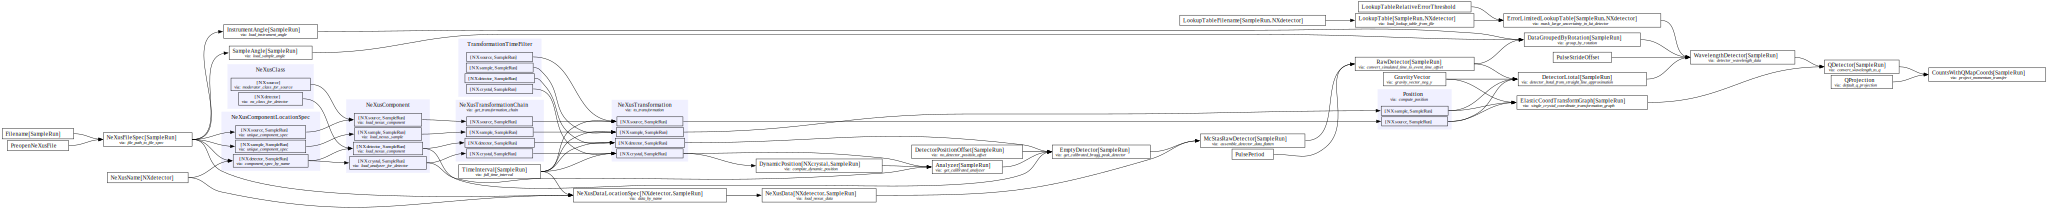

In [5]:
workflow.visualize(CountsWithQMapCoords[SampleRun], graph_attr={"rankdir": "LR"})

In [6]:
counts = workflow.compute(CountsWithQMapCoords[SampleRun])

Make an interactive figure.
Use the slider to select a range in $Q$ to integrate over and display in the 1D figure.

In [7]:
make_q_map(counts,
           q_parallel_bins=sc.linspace('Q_parallel', -4.5, 4.5, 100, unit='1/Å'),
           q_perpendicular_bins=sc.linspace('Q_perpendicular', -4.5, 4.5, 100, unit='1/Å'),
           sample_rotation_bins=sc.scalar(1.0, unit='deg'),
           )

Box(children=(HBar(children=(InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(childre…